In [1]:
import numpy as np

# Load representative simulated Raman spectra
simulatedInput = np.load('./Raman_Data/simulated_input.npy')
simulatedPeak = np.load('./Raman_Data/simulated_peak.npy')
simulatedBaseline = np.load('./Raman_Data/simulated_baseline.npy')

print(f'Input shape    : {simulatedInput.shape}')
print(f'Peak shape     : {simulatedPeak.shape}')
print(f'Baseline shape : {simulatedBaseline.shape}')

Input shape    : (10, 512)
Peak shape     : (10, 512)
Baseline shape : (10, 512)


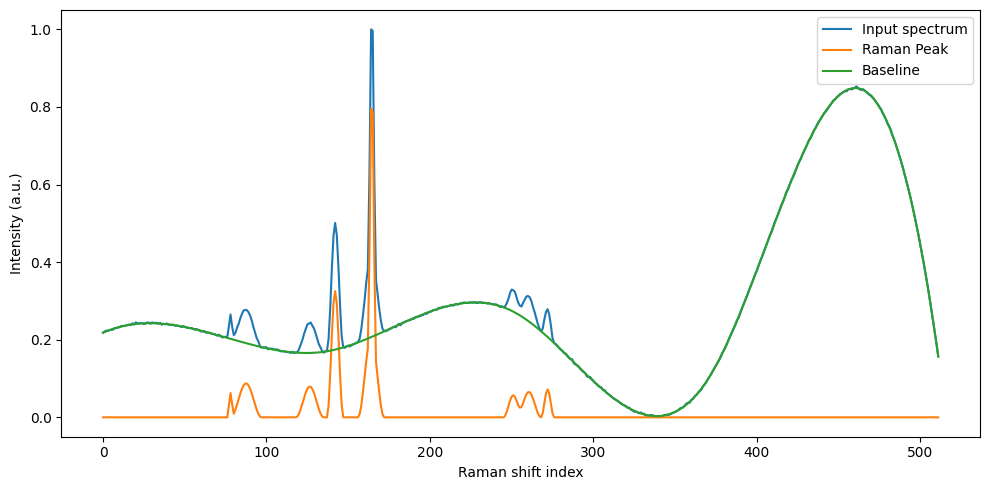

In [2]:
import matplotlib.pyplot as plt

sampleIndex = 0

plt.figure(figsize=(10, 5))

plt.plot(simulatedInput[sampleIndex], label='Input spectrum')
plt.plot(simulatedPeak[sampleIndex], label='Raman Peak')
plt.plot(simulatedBaseline[sampleIndex], label='Baseline')

plt.xlabel('Raman shift index')
plt.ylabel('Intensity (a.u.)')
plt.legend()
plt.tight_layout()
plt.show()

Experimental spectra : (10, 2329)
Labels               : (10,)


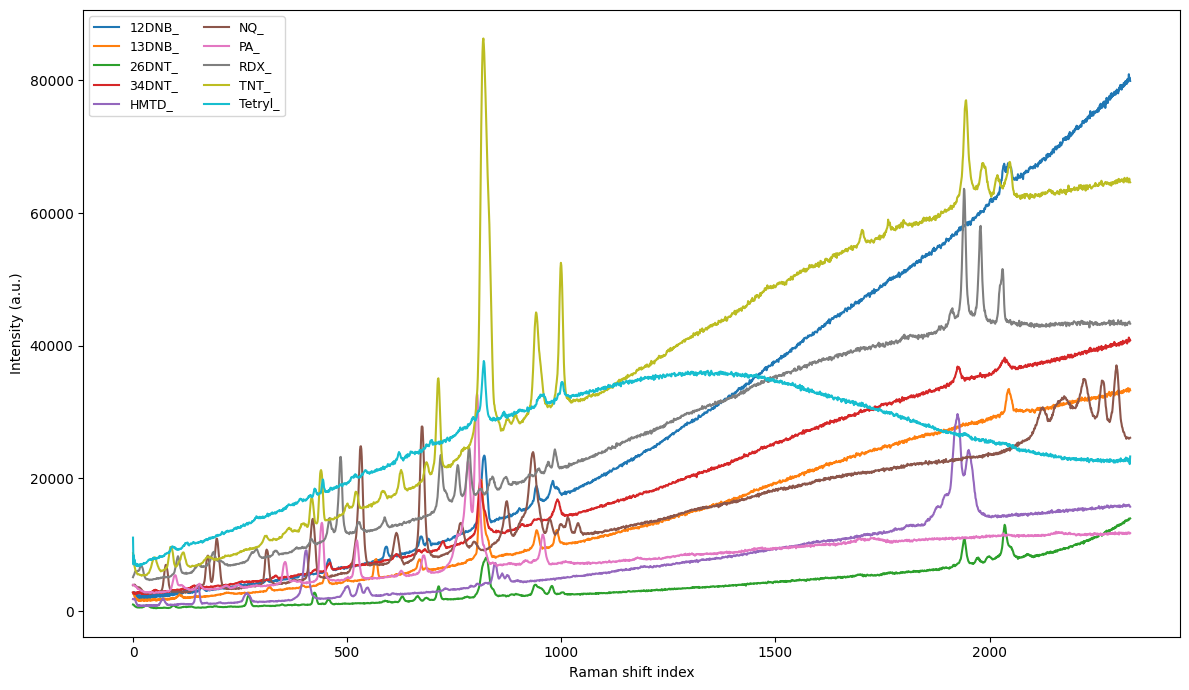

In [3]:
import numpy as np
import matplotlib.pyplot as plt

experimentalRaw = np.load(
    './Raman_Data/experimental_raw.npy'
)

experimentalLabels = np.load(
    './Raman_Data/experimental_labels.npy'
)

print("Experimental spectra :", experimentalRaw.shape)
print("Labels               :", experimentalLabels.shape)


plt.figure(figsize=(12, 7))

for i in range(len(experimentalRaw)):
    plt.plot(
        experimentalRaw[i],
        label=experimentalLabels[i],
        linewidth=1.5
    )

plt.xlabel("Raman shift index")
plt.ylabel("Intensity (a.u.)")

plt.legend(
    fontsize=9,
    ncol=2
)

plt.tight_layout()
plt.show()

In [4]:
import torch
from DU_GridNet import DUGridNet

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = DUGridNet().to(device)

checkpoint = torch.load(
    "./DU-GridNet.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["modelState"],
    strict=True
)

model.eval()

print("DU-GridNet loaded successfully.")

DU-GridNet loaded successfully.


In [5]:
simulatedInput = np.load(
    "./Raman_Data/simulated_input.npy"
).astype(np.float32)

simulatedPeak = np.load(
    "./Raman_Data/simulated_peak.npy"
).astype(np.float32)

simulatedBaseline = np.load(
    "./Raman_Data/simulated_baseline.npy"
).astype(np.float32)

print("Input    :", simulatedInput.shape)
print("Peak     :", simulatedPeak.shape)
print("Baseline :", simulatedBaseline.shape)


# =========================================================
# DU-GridNet inference
# =========================================================

inputTensor = torch.from_numpy(
    simulatedInput
).to(
    device=device,
    dtype=torch.float32
)

with torch.no_grad():
    baselineTensor = model(
        inputTensor
    )

estimatedBaseline = (
    baselineTensor
    .detach()
    .cpu()
    .numpy()
    .reshape(simulatedInput.shape)
)

correctedSpectrum = (
    simulatedInput
    - estimatedBaseline
)

print(
    "Estimated baseline:",
    estimatedBaseline.shape
)

print(
    "Corrected spectrum:",
    correctedSpectrum.shape
)

Input    : (10, 512)
Peak     : (10, 512)
Baseline : (10, 512)
Estimated baseline: (10, 512)
Corrected spectrum: (10, 512)


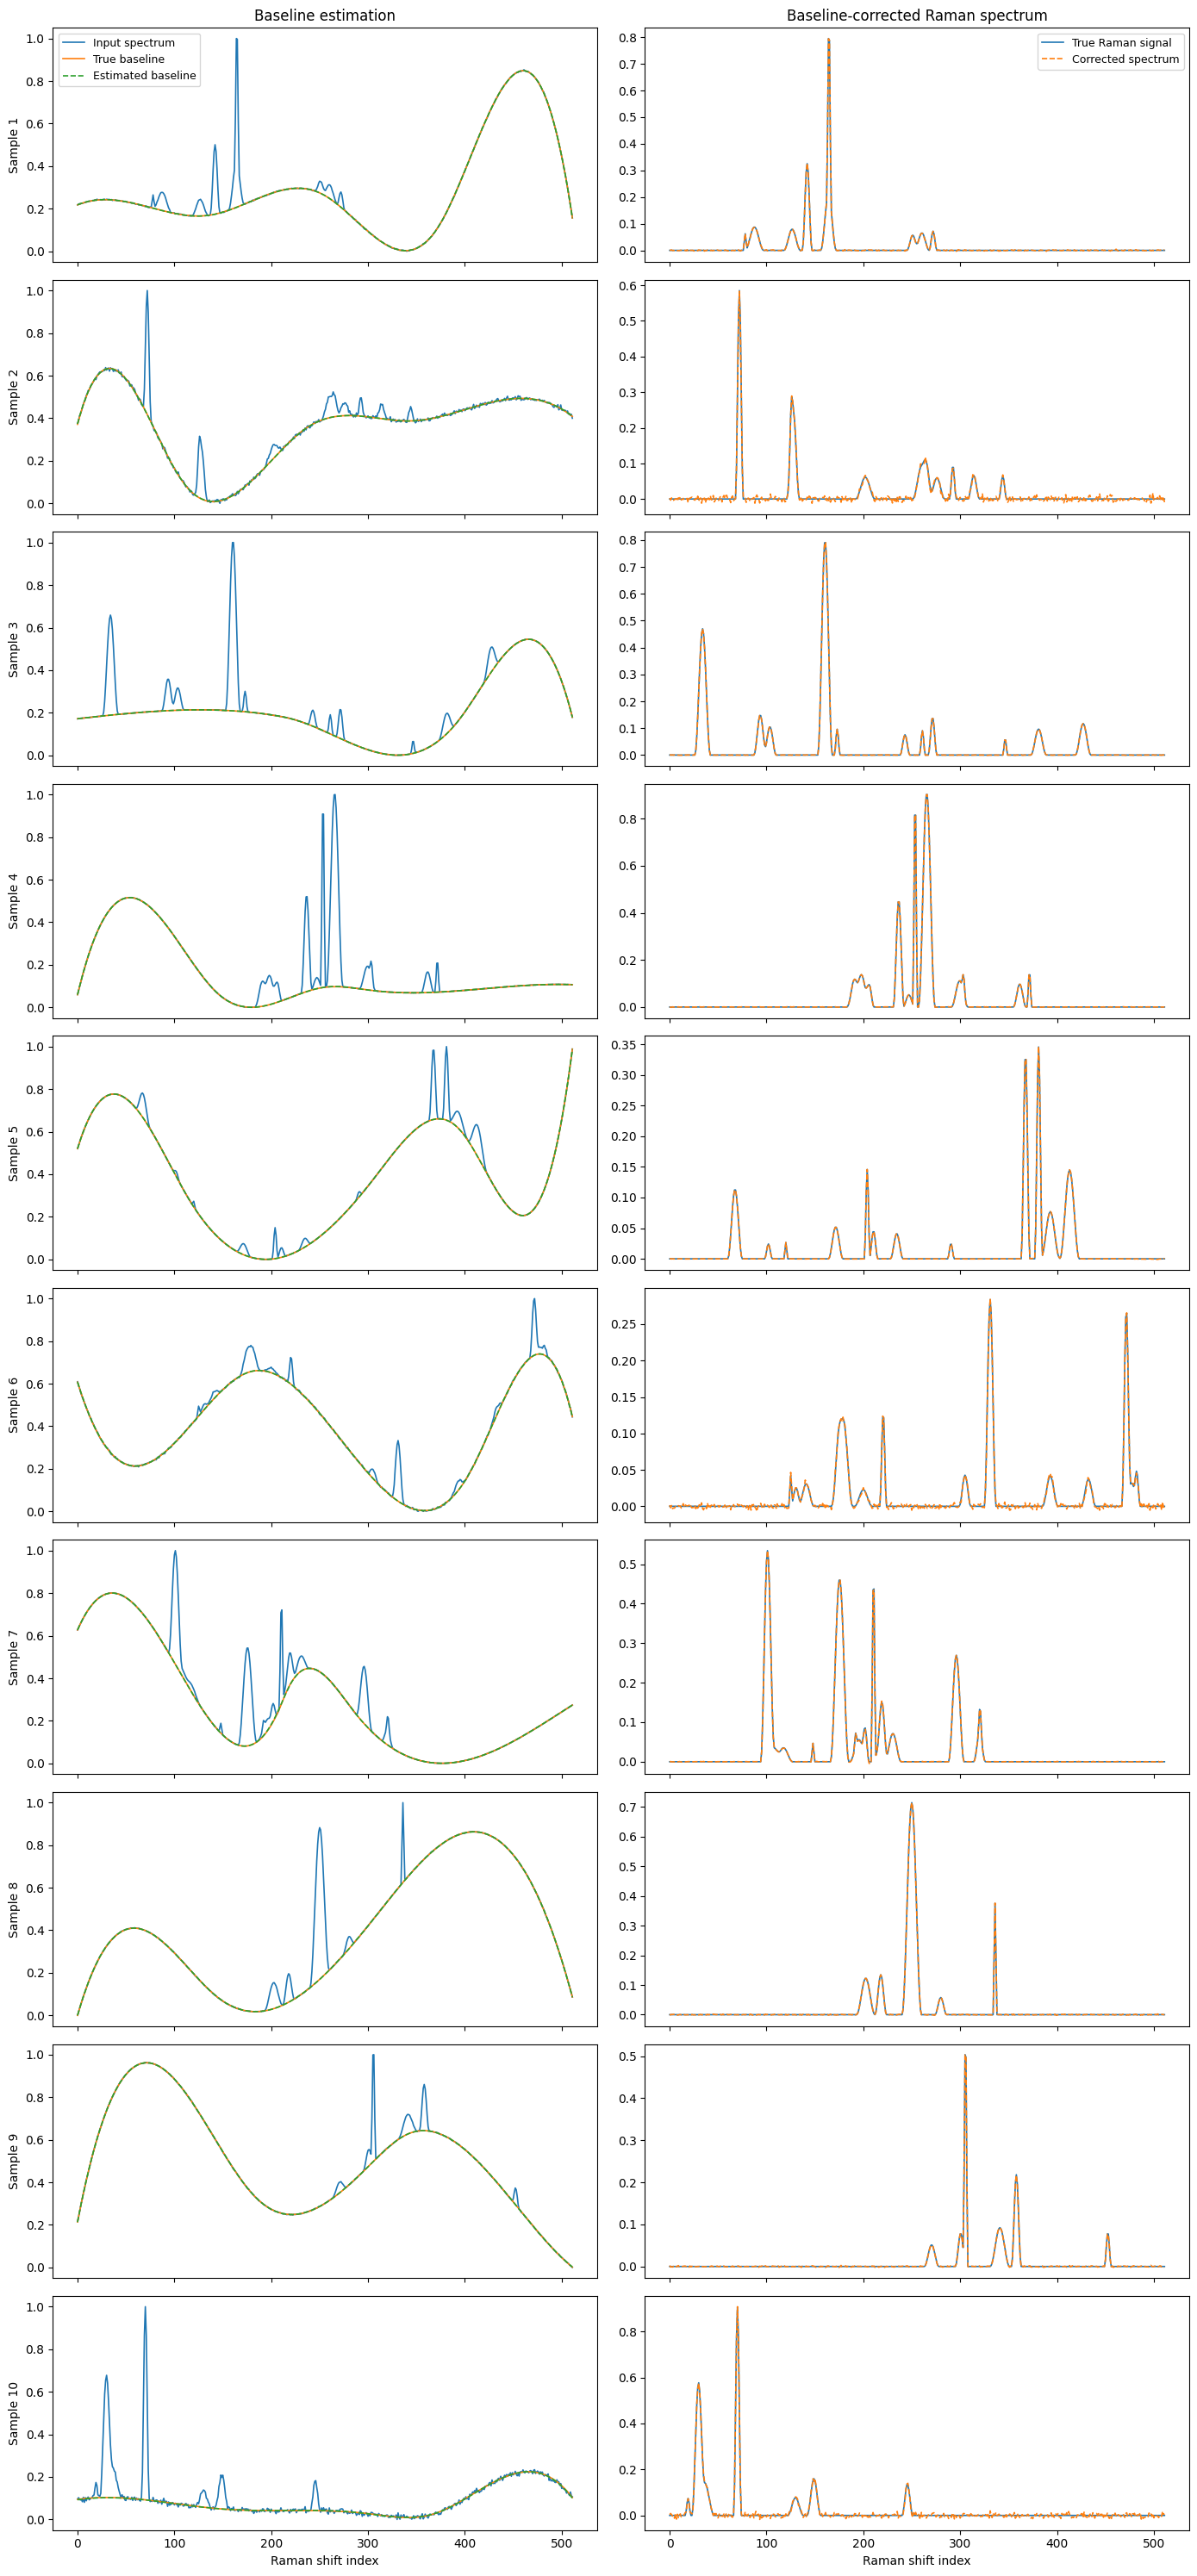

In [6]:
numSamples = len(simulatedInput)

fig, axes = plt.subplots(
    nrows=numSamples,
    ncols=2,
    figsize=(14, 3 * numSamples),
    sharex=True
)

xAxis = np.arange(
    simulatedInput.shape[1]
)

for i in range(numSamples):
    axes[i, 0].plot(
        xAxis,
        simulatedInput[i],
        label="Input spectrum",
        linewidth=1.2
    )

    axes[i, 0].plot(
        xAxis,
        simulatedBaseline[i],
        label="True baseline",
        linewidth=1.2
    )

    axes[i, 0].plot(
        xAxis,
        estimatedBaseline[i],
        linestyle="--",
        label="Estimated baseline",
        linewidth=1.2
    )

    axes[i, 0].set_ylabel(
        f"Sample {i + 1}"
    )

    axes[i, 1].plot(
        xAxis,
        simulatedPeak[i],
        label="True Raman signal",
        linewidth=1.2
    )

    axes[i, 1].plot(
        xAxis,
        correctedSpectrum[i],
        linestyle="--",
        label="Corrected spectrum",
        linewidth=1.2
    )

    if i == 0:
        axes[i, 0].legend(
            fontsize=9
        )

        axes[i, 1].legend(
            fontsize=9
        )

axes[-1, 0].set_xlabel(
    "Raman shift index"
)

axes[-1, 1].set_xlabel(
    "Raman shift index"
)

axes[0, 0].set_title(
    "Baseline estimation"
)

axes[0, 1].set_title(
    "Baseline-corrected Raman spectrum"
)

plt.tight_layout()
plt.show()

Experimental input : (10, 512)
Labels             : (10,)
Estimated baseline : (10, 512)
Corrected spectra  : (10, 512)


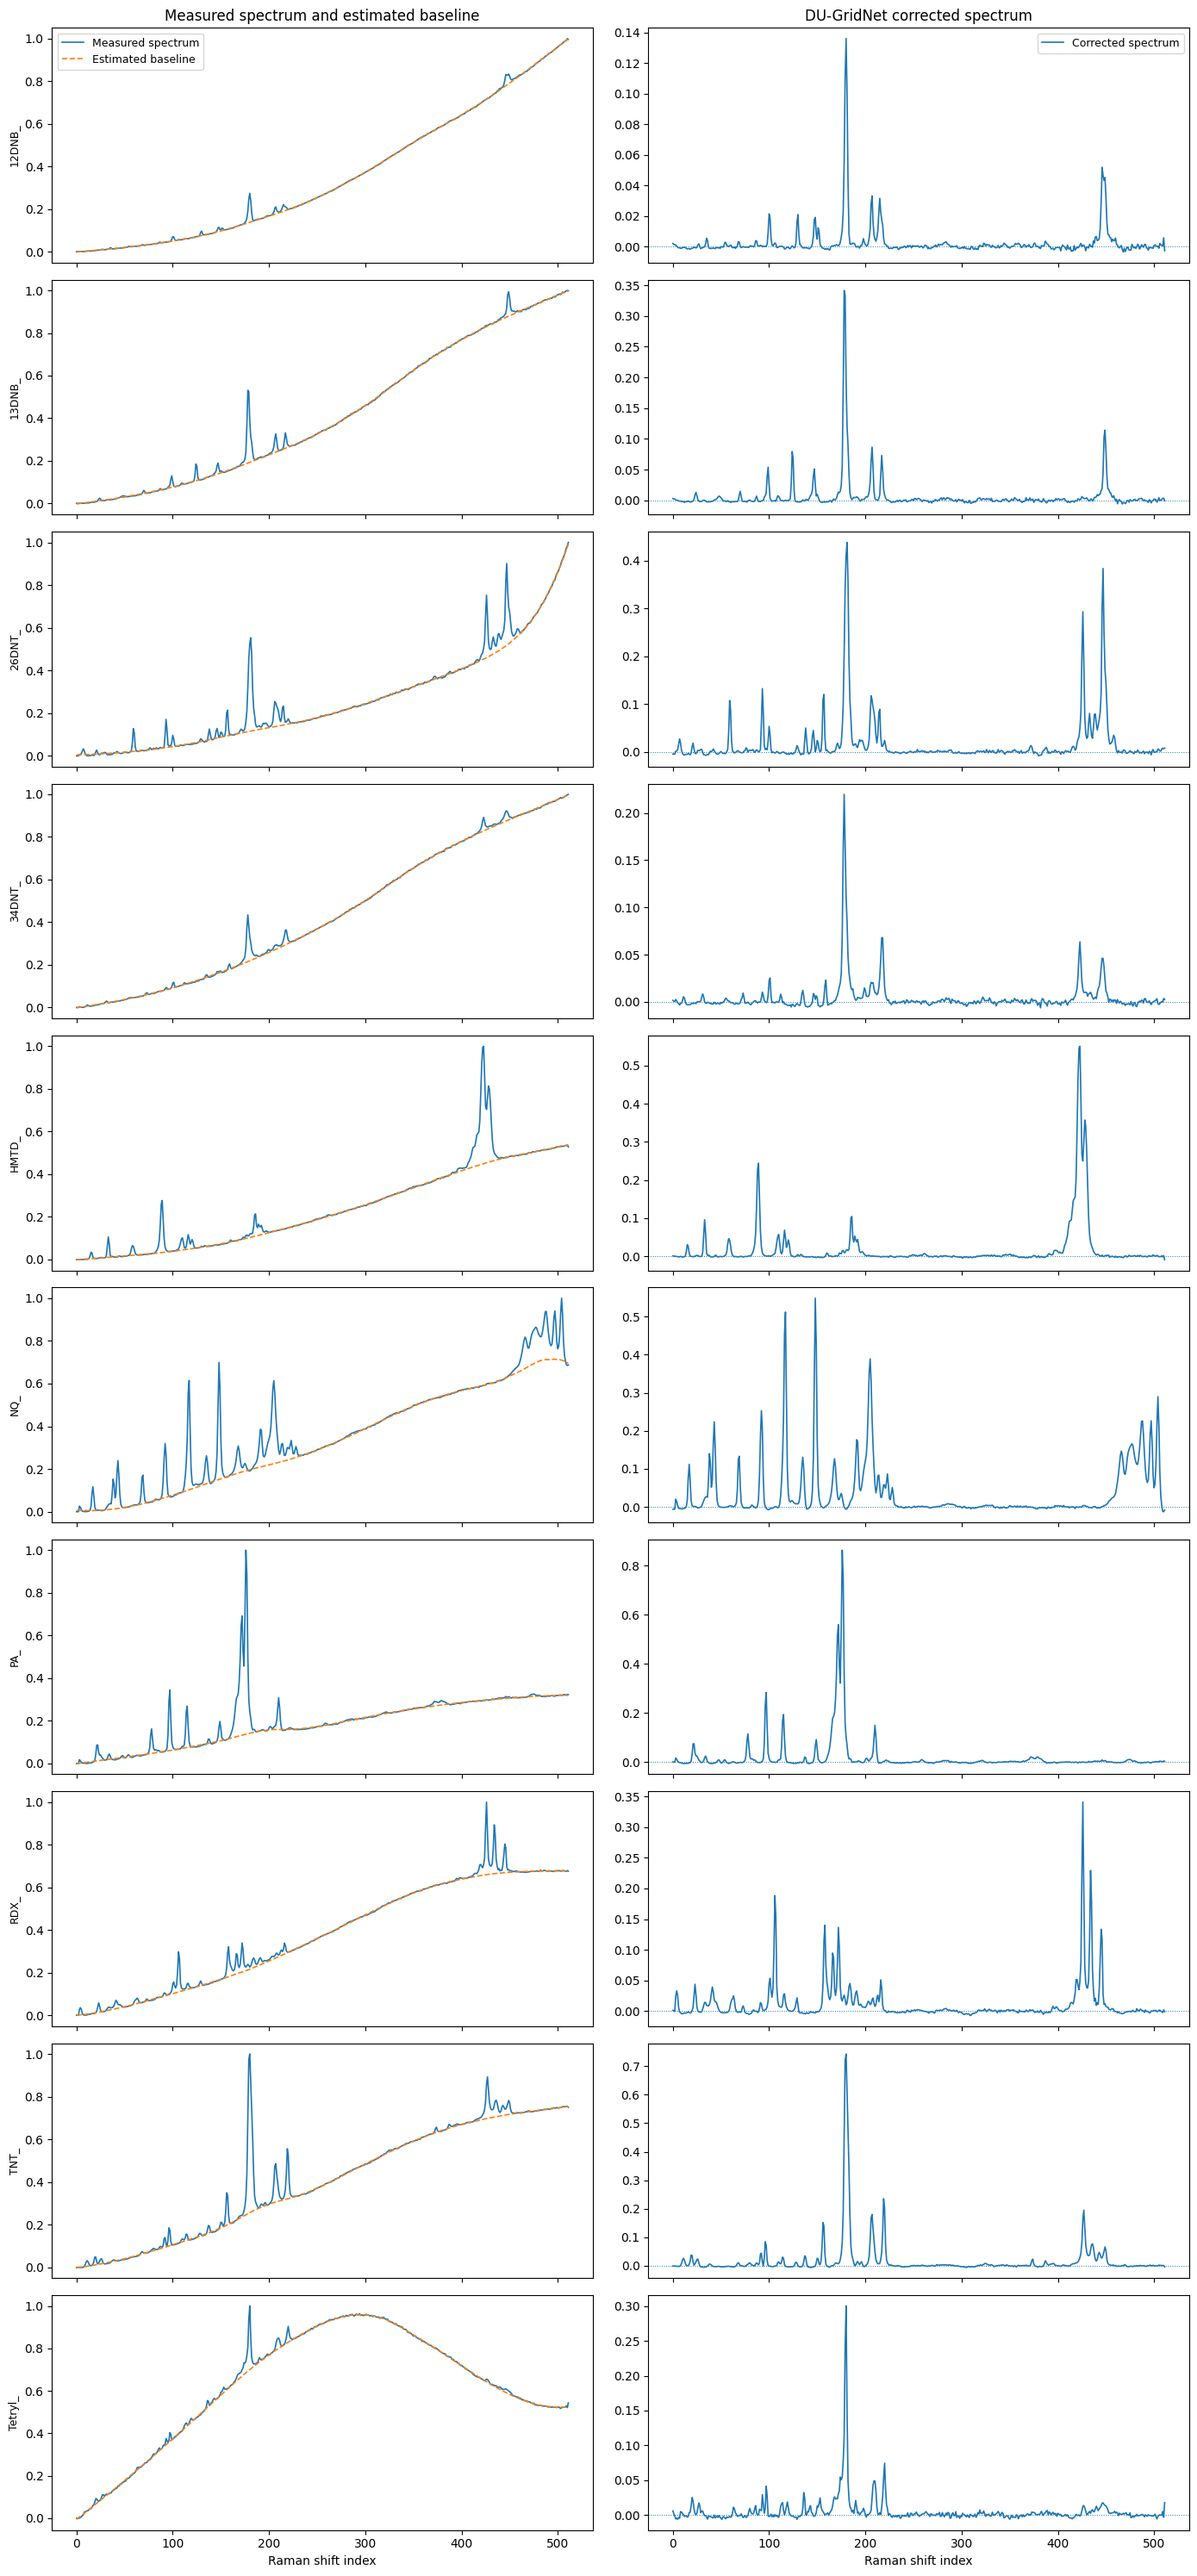

In [7]:
experimentalInput = np.load(
    "./data/experimental_input.npy"
).astype(np.float32)

experimentalLabels = np.load(
    "./data/experimental_labels.npy"
)

print("Experimental input :", experimentalInput.shape)
print("Labels             :", experimentalLabels.shape)


inputTensor = torch.from_numpy(
    experimentalInput
).to(
    device=device,
    dtype=torch.float32
)

with torch.no_grad():
    baselineTensor = model(
        inputTensor
    )

experimentalBaseline = (
    baselineTensor
    .detach()
    .cpu()
    .numpy()
    .reshape(
        experimentalInput.shape
    )
)

experimentalCorrected = (
    experimentalInput
    - experimentalBaseline
)

print(
    "Estimated baseline :",
    experimentalBaseline.shape
)

print(
    "Corrected spectra  :",
    experimentalCorrected.shape
)

numSamples = len(
    experimentalInput
)

xAxis = np.arange(
    experimentalInput.shape[1]
)

fig, axes = plt.subplots(
    nrows=numSamples,
    ncols=2,
    figsize=(14, 3 * numSamples),
    sharex=True
)

for i in range(numSamples):

    
    axes[i, 0].plot(
        xAxis,
        experimentalInput[i],
        label="Measured spectrum",
        linewidth=1.2
    )

    axes[i, 0].plot(
        xAxis,
        experimentalBaseline[i],
        linestyle="--",
        label="Estimated baseline",
        linewidth=1.2
    )

    axes[i, 0].set_ylabel(
        str(experimentalLabels[i]),
        fontsize=9
    )

    
    axes[i, 1].plot(
        xAxis,
        experimentalCorrected[i],
        label="Corrected spectrum",
        linewidth=1.2
    )

    axes[i, 1].axhline(
        0,
        linewidth=0.7,
        linestyle=":"
    )

    if i == 0:
        axes[i, 0].legend(
            fontsize=9
        )

        axes[i, 1].legend(
            fontsize=9
        )

axes[-1, 0].set_xlabel(
    "Raman shift index"
)

axes[-1, 1].set_xlabel(
    "Raman shift index"
)

axes[0, 0].set_title(
    "Measured spectrum and estimated baseline"
)

axes[0, 1].set_title(
    "DU-GridNet corrected spectrum"
)

plt.tight_layout()
plt.show()